# Guía de Ejercicios 3 — Inteligencia Artificial

## Diferencias-en-diferencias escalonado: el efecto de los SLEP

Sergio Hernández — `shernandez@ucm.cl` — Universidad Católica del Maule

---

La guía anterior terminó en un empate. Comparando tasas crudas, el **Servicio
Local de Educación Pública** (SLEP) desvinculaba 0,49 puntos porcentuales menos
que el sector municipal del que heredó la matrícula. Ajustando por puerta
trasera, la ventaja bajaba a 0,41 pp — pero ese ajuste era inválido, porque el
SLEP no existe antes de 2018 y la **positividad** fallaba. Sobre el soporte
común (2018–2024) la diferencia se iba a 0,02 pp: nada.

Y aun así no podíamos concluir. Quedaba un confusor no medido que ningún ajuste
sobre esa tabla arregla: **los SLEP no recibieron comunas al azar**. La Ley
21.040 traspasó territorios en un calendario escalonado, y el sector municipal
que queda como comparación es otro conjunto de comunas, con otro nivel
socioeconómico, otra ruralidad y otro tamaño.

Esta guía usa precisamente lo que allá era un estorbo. Que el traspaso ocurriera
**en distintos momentos** permite comparar cada comuna consigo misma antes y
después, usando como control las comunas aún no traspasadas. Es el diseño de
**diferencias-en-diferencias escalonado** (*staggered difference-in-differences*).

| Guía 2 | Guía 3 |
|---|---|
| unidad: celda (año, sexo, dependencia) | unidad: comuna × año |
| identificación: puerta trasera | identificación: tendencias paralelas |
| supuesto: el DAG está completo | supuesto: sin el traspaso, tratadas y controles evolucionaban igual |
| falla detectada: positividad | falla a detectar: ¿se sostiene el supuesto? |

### La advertencia de siempre

El diseño es mejor. Eso no garantiza que funcione. Un DiD escalonado tiene
supuestos propios, y a diferencia de la puerta trasera, **uno de ellos deja
huellas comprobables en los datos**. Buena parte de esta guía consiste en
buscarlas.

---
## 0. Caja de herramientas

In [1]:
# !pip install pymc arviz pandas matplotlib openpyxl

import logging
import unicodedata
import warnings
from pathlib import Path

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm

# PyMC narra cada ajuste por el log; con una decena de modelos, ese ruido tapa
# los resultados. Solo queremos ver errores.
logging.getLogger("pymc").setLevel(logging.ERROR)
# El ESS bajo de los 346 efectos de comuna es esperable y no afecta a los
# coeficientes de interes: `resumen` reporta ess y r_hat de cada uno.
warnings.filterwarnings("ignore", message=".*effective sample size.*")
warnings.filterwarnings("ignore", message=".*rhat statistic.*")
warnings.filterwarnings("ignore", category=RuntimeWarning, module=".*quadpotential.*")

SEMILLA = 20260901
rng = np.random.default_rng(SEMILLA)
pd.set_option("display.width", 120)


def check(nombre, condicion, pista=""):
    print(f"[{'OK      ' if condicion else 'REVISAR '}] {nombre}"
          + (f"   -> {pista}" if (not condicion and pista) else ""))
    return bool(condicion)


def pp(logit, base=0.015):
    # Traduce un coeficiente logit a puntos porcentuales sobre una tasa base.
    # Todo el modelo vive en escala logit; los efectos hay que leerlos en pp.
    return 100 * base * (np.exp(logit) - 1)


def resumen(idata, var, base=0.015, etiqueta=None, solo_logit=False):
    # Media posterior e intervalo del 95% de un coeficiente, en logit y en pp.
    # solo_logit=True para parametros que no son efectos (una desviacion
    # estandar no se traduce a puntos porcentuales).
    m = idata.posterior[var].values.reshape(-1)
    lo, hi = np.percentile(m, [2.5, 97.5])
    linea = f"{etiqueta or var:<24} logit {m.mean():+.4f} [{lo:+.4f}, {hi:+.4f}]"
    if not solo_logit:
        linea += (f"   {pp(m.mean(), base):+.3f} pp"
                  f" [{pp(lo, base):+.3f}, {pp(hi, base):+.3f}]")
    dg = az.summary(idata, var_names=[var])
    linea += f"   [ess {int(dg.ess_bulk.iloc[0])}, r_hat {dg.r_hat.iloc[0]:.2f}]"
    print(linea)
    return m


print("Herramientas cargadas.")

Herramientas cargadas.


---
# 1. Los datos

Dos fuentes que hay que unir por el nombre de la comuna: el panel de resultados
del MINEDUC y el calendario de instalación de los SLEP.

## 1.1 El panel de desvinculación por comuna

Misma planilla de la guía anterior, otra hoja: «Tasas a nivel de Comuna». Trae
346 comunas × 15 años, y para cada celda los **desvinculados** y la **matrícula
teórica**. A diferencia de la hoja de dependencia, ésta **no separa por
sostenedor**: la tasa de una comuna mezcla sus colegios municipales, particulares
subvencionados y pagados. Volveremos sobre esa limitación en la sección 2.3,
porque cambia lo que el efecto estimado significa.

In [2]:
HOJA = "Tasas a nivel de Comuna"
ANIOS = list(range(2010, 2025))


def ruta_datos(nombre="OFICIAL-Tasa-Incidencia-Desvinculacion-2010-2024.xlsx"):
    for base in [Path("."), Path(".."), Path("../.."), Path("../../..")]:
        cand = base / "data" / nombre
        if cand.exists():
            return cand
    raise FileNotFoundError(f"No se encontro data/{nombre}")


def cargar_comunas(ruta=None):
    # La hoja apila tres tablas (total, mujeres, hombres). Usamos la primera.
    # Cada anio ocupa 6 columnas: Global(desv, matricula, tasa) y luego lo mismo
    # restringido al sistema regular. Nos quedamos con las columnas Global.
    hoja = pd.read_excel(ruta or ruta_datos(), sheet_name=HOJA, header=None)
    filas = []
    for i in range(4, 350):                       # Tabla 6, antes del TOTAL
        nombre = hoja.iat[i, 0]
        if not isinstance(nombre, str) or nombre.strip().upper() == "TOTAL":
            continue
        for j, anio in enumerate(ANIOS):
            c = 1 + 6 * j
            filas.append({"comuna": nombre.strip(), "anio": anio,
                          "desv": hoja.iat[i, c], "mat": hoja.iat[i, c + 1]})
    t = pd.DataFrame(filas)
    # El guion "-" marca ausencia de informacion, no un cero.
    t["desv"] = pd.to_numeric(t.desv, errors="coerce")
    t["mat"] = pd.to_numeric(t.mat, errors="coerce")
    return t


panel = cargar_comunas()
print(f"{panel.comuna.nunique()} comunas x {panel.anio.nunique()} anios "
      f"= {len(panel)} celdas ({panel.mat.isna().sum()} sin informacion)")

nacional = (panel.groupby("anio").apply(lambda x: 100 * x.desv.sum() / x.mat.sum(),
                                        include_groups=False))
print("\nTasa nacional por anio (%):")
print(nacional.round(2).to_string())

346 comunas x 15 anios = 5190 celdas (8 sin informacion)

Tasa nacional por anio (%):
anio
2010    1.92
2011    2.29
2012    2.10
2013    1.92
2014    1.73
2015    1.60
2016    1.52
2017    1.45
2018    1.38
2019    1.55
2020    0.93
2021    1.47
2022    1.66
2023    1.57
2024    1.33


In [3]:
# Verificacion: esta hoja tiene que reproducir la serie nacional de la guia 2,
# que salia de la hoja de dependencia. Son dos desagregaciones del mismo total.
esperado = {2010: 1.92, 2015: 1.61, 2020: 0.93, 2024: 1.33}
for anio, valor in esperado.items():
    check(f"tasa nacional {anio} ~ {valor}%",
          abs(nacional[anio] - valor) < 0.02,
          f"obtenido {nacional[anio]:.2f}%")

[OK      ] tasa nacional 2010 ~ 1.92%
[OK      ] tasa nacional 2015 ~ 1.61%
[OK      ] tasa nacional 2020 ~ 0.93%
[OK      ] tasa nacional 2024 ~ 1.33%


## 1.2 El calendario de instalación de los SLEP

La Ley 21.040 (2017) creó 70 Servicios Locales, cada uno agrupando un conjunto
de comunas, con entrada en funcionamiento escalonada entre 2017 y 2029. Ése es
el **calendario de tratamiento**: la variable clave del diseño no es «¿es SLEP?»
sino «¿en qué año pasó a serlo?».

> **Fuente.** [Servicios Locales de Educación Pública](https://es.wikipedia.org/wiki/Servicios_Locales_de_Educaci%C3%B3n_P%C3%BAblica),
> Wikipedia en español, consultada el 1 de septiembre de 2026.

> **Una ambigüedad que hay que declarar.** Entre la *creación* legal de un SLEP,
> su *instalación* y el traspaso efectivo de los establecimientos puede pasar
> casi un año, y las fuentes no siempre distinguen. Tomamos el año de la tabla
> como primer año tratado y en la sección 6 repetimos todo desplazándolo ±1 año.
> Si la conclusión cambiara con ese desplazamiento, no sería una conclusión.

In [4]:
# Calendario de instalacion de los Servicios Locales de Educacion Publica.
# Fuente: https://es.wikipedia.org/wiki/Servicios_Locales_de_Educacion_Publica
# (nombre del SLEP, anio de entrada en funcionamiento, comunas que agrupa)
SLEP = [
    ("Chinchorro", 2019, ["Arica", "Camarones", "Putre", "General Lagos"]),
    ("Iquique", 2024, ["Iquique", "Alto Hospicio"]),
    ("Tamarugal", 2026, ["Pozo Almonte", "Camina", "Colchane", "Huara", "Pica"]),
    ("Licancabur", 2025, ["Calama", "Ollague", "San Pedro de Atacama", "Tocopilla",
                          "Maria Elena"]),
    ("Antofagasta", 2027, ["Antofagasta", "Mejillones", "Sierra Gorda", "Taltal"]),
    ("Atacama", 2020, ["Copiapo", "Caldera", "Tierra Amarilla", "Chanaral",
                       "Diego de Almagro"]),
    ("Huasco", 2018, ["Alto del Carmen", "Freirina", "Huasco", "Vallenar"]),
    ("Puerto Cordillera", 2017, ["Coquimbo", "Andacollo"]),
    ("Elqui", 2023, ["La Serena", "La Higuera", "Paihuano", "Vicuna"]),
    ("Limari", 2025, ["Ovalle", "Combarbala", "Monte Patria", "Punitaqui",
                      "Rio Hurtado"]),
    ("Choapa", 2025, ["Illapel", "Canela", "Los Vilos", "Salamanca"]),
    ("Valparaiso", 2020, ["Valparaiso", "Juan Fernandez"]),
    ("Costa Central", 2023, ["Concon", "Puchuncavi", "Quintero", "Vina del Mar"]),
    ("Petorca", 2026, ["La Ligua", "Cabildo", "Papudo", "Petorca", "Zapallar"]),
    ("Los Andes", 2026, ["Los Andes", "Calle Larga", "Rinconada", "San Esteban"]),
    ("Quillota", 2025, ["Quillota", "La Calera", "Hijuelas", "La Cruz", "Nogales"]),
    ("Marga Marga", 2026, ["Quilpue", "Limache", "Olmue", "Villa Alemana"]),
    ("Litoral", 2024, ["San Antonio", "Algarrobo", "Cartagena", "El Quisco",
                       "El Tabo", "Casablanca", "Santo Domingo"]),
    ("Aconcagua", 2026, ["San Felipe", "Catemu", "Llay-Llay", "Panquehue",
                         "Putaendo", "Santa Maria"]),
    ("Hanga Roa", 2025, ["Isla de Pascua"]),
    ("Santiago Centro", 2026, ["Santiago"]),
    ("Maipo Sur", 2025, ["Buin", "Paine"]),
    ("Santa Corina", 2025, ["Cerrillos", "Estacion Central", "Maipu"]),
    ("Chacabuco", 2025, ["Colina", "Lampa", "Tiltil"]),
    ("Los Libertadores", 2025, ["Conchali", "Quilicura"]),
    ("Del Pino", 2025, ["El Bosque", "La Pintana", "San Bernardo",
                        "Calera de Tango"]),
    ("Mapocho", 2028, ["Huechuraba", "Independencia", "Recoleta"]),
    ("Santa Rosa", 2025, ["La Cisterna", "Lo Espejo", "Pedro Aguirre Cerda",
                          "San Miguel", "San Ramon"]),
    ("La Quebrada", 2027, ["La Florida", "Nunoa", "Penalolen"]),
    ("Manquehue", 2029, ["La Reina", "Las Condes", "Lo Barnechea", "Providencia",
                         "Vitacura"]),
    ("Gabriela Mistral", 2020, ["Macul", "San Joaquin", "La Granja"]),
    ("Melipilla", 2025, ["Melipilla", "Alhue", "Curacavi", "Maria Pinto",
                         "San Pedro"]),
    ("Barrancas", 2017, ["Pudahuel", "Lo Prado", "Cerro Navia"]),
    ("Los Vinedos", 2025, ["Puente Alto", "Pirque", "San Jose de Maipo"]),
    ("Los Parques", 2026, ["Quinta Normal", "Renca"]),
    ("Talagante", 2024, ["Talagante", "El Monte", "Isla de Maipo", "Padre Hurtado",
                         "Penaflor"]),
    ("Colchagua", 2020, ["San Fernando", "Chimbarongo", "Nancagua", "Placilla"]),
    ("Costa Colchagua", 2024, ["Chepica", "Lolol", "Palmilla", "Peralillo",
                               "Pumanque", "Santa Cruz"]),
    ("Valle Cachapoal", 2027, ["Coinco", "Coltauco", "Donihue", "Malloa",
                               "Quinta de Tilcoco", "Rengo", "Requinoa"]),
    ("Cachapoal Costa", 2025, ["Las Cabras", "Peumo", "Pichidegua", "San Vicente"]),
    ("Cardenal Caro", 2025, ["Pichilemu", "La Estrella", "Litueche", "Marchigue",
                             "Navidad", "Paredones"]),
    ("Cachapoal Norte", 2025, ["Rancagua", "Codegua", "Graneros", "Machali",
                               "Mostazal", "Olivar"]),
    ("Maule Costa", 2025, ["Constitucion", "Empedrado", "Cauquenes", "Chanco",
                           "Pelluhue"]),
    ("Los Cerezos", 2024, ["Curepto", "Rio Claro", "Curico", "Hualane", "Licanten",
                           "Molina", "Rauco", "Romeral", "Sagrada Familia", "Teno",
                           "Vichuquen"]),
    ("Los Alamos", 2026, ["Linares", "Colbun", "Longavi", "Parral", "Retiro",
                          "Villa Alegre", "Yerbas Buenas"]),
    ("Maule Valle", 2024, ["Talca", "Maule", "Pelarco", "Pencahue", "San Clemente",
                           "San Rafael", "San Javier"]),
    ("Valle Diguillin", 2026, ["Chillan", "Bulnes", "Chillan Viejo", "El Carmen",
                               "Pemuco", "San Ignacio", "Yungay"]),
    ("Costa Itata", 2025, ["Cobquecura", "Coelemu", "Ninhue", "Portezuelo",
                           "Quillon", "Quirihue", "Ranquil", "San Nicolas",
                           "Treguaco"]),
    ("Punilla Cordillera", 2024, ["Coihueco", "Niquen", "Pinto", "San Carlos",
                                  "San Fabian"]),
    ("Andalien Sur", 2019, ["Concepcion", "Chiguayante", "Hualqui", "Florida"]),
    ("Puelche", 2026, ["Antuco", "Mulchen", "Quilaco", "Quilleco", "Santa Barbara",
                       "Tucapel", "Alto Biobio"]),
    ("Arauco Sur", 2025, ["Canete", "Contulmo", "Tirua", "Los Alamos"]),
    ("Andalien Costa", 2025, ["Coronel", "Lota", "San Pedro de la Paz",
                              "Santa Juana"]),
    ("Valle Biobio", 2025, ["Laja", "Nacimiento", "Negrete", "San Rosendo"]),
    ("Arauco Norte", 2025, ["Lebu", "Arauco", "Curanilahue"]),
    ("Los Copihues", 2024, ["Los Angeles", "Cabrero", "Yumbel"]),
    ("Las Caletas", 2025, ["Penco", "Talcahuano", "Tome", "Hualpen"]),
    ("Costa Araucania", 2018, ["Carahue", "Nueva Imperial", "Saavedra",
                               "Teodoro Schmidt", "Tolten"]),
    ("Malleco Costa", 2027, ["Angol", "Los Sauces", "Lumaco", "Puren", "Renaico",
                             "Traiguen"]),
    ("Malleco Cordillera", 2027, ["Collipulli", "Curacautin", "Ercilla",
                                  "Lonquimay", "Victoria"]),
    ("Cautin Sur", 2025, ["Cunco", "Curarrehue", "Freire", "Gorbea", "Loncoche",
                          "Melipeuco", "Padre Las Casas", "Pitrufquen", "Pucon",
                          "Villarrica"]),
    ("Cautin Norte", 2025, ["Temuco", "Galvarino", "Lautaro", "Perquenco",
                            "Vilcun", "Cholchol"]),
    ("Ranco", 2025, ["La Union", "Futrono", "Lago Ranco", "Rio Bueno"]),
    ("Valdivia", 2025, ["Valdivia", "Corral", "Lanco", "Los Lagos", "Mafil",
                        "Mariquina", "Paillaco", "Panguipulli"]),
    ("Llanquihue", 2020, ["Fresia", "Frutillar", "Los Muermos", "Llanquihue",
                          "Puerto Varas"]),
    ("Chiloe", 2024, ["Castro", "Ancud", "Chonchi", "Curaco de Velez", "Dalcahue",
                      "Puqueldon", "Queilen", "Quellon", "Quemchi", "Quinchao"]),
    ("Osorno", 2025, ["Osorno", "Puerto Octay", "Purranque", "Puyehue",
                      "Rio Negro", "San Juan de la Costa", "San Pablo"]),
    ("Reloncavi", 2024, ["Puerto Montt", "Calbuco", "Cochamo", "Maullin",
                         "Chaiten", "Futaleufu", "Hualaihue", "Palena"]),
    ("Aysen", 2024, ["Coyhaique", "Lago Verde", "Aysen", "Cisnes", "Guaitecas",
                     "Cochrane", "O'Higgins", "Tortel", "Chile Chico",
                     "Rio Ibanez"]),
    ("Magallanes", 2024, ["Punta Arenas", "Laguna Blanca", "Rio Verde",
                          "San Gregorio", "Cabo de Hornos", "Antartica",
                          "Porvenir", "Primavera", "Timaukel", "Natales",
                          "Torres del Paine"]),
]

# Grafias alternas: Wikipedia usa el nombre corriente, el MINEDUC el oficial.
ALIAS = {"PAIHUANO": "PAIGUANO", "LA CALERA": "CALERA", "LLAY LLAY": "LLAILLAY",
         "MARCHIGUE": "MARCHIHUE", "COYHAIQUE": "COIHAIQUE", "AYSEN": "AISEN"}

print(f"{len(SLEP)} servicios locales, "
      f"{sum(len(c) for _, _, c in SLEP)} comunas asignadas")
print("\nComunas por anio de entrada en funcionamiento:")
cal = pd.Series([a for _, a, cs in SLEP for _ in cs]).value_counts().sort_index()
print(cal.to_string())

70 servicios locales, 346 comunas asignadas

Comunas por anio de entrada en funcionamiento:
2017      5
2018      9
2019      8
2020     19
2023      8
2024     85
2025    131
2026     48
2027     25
2028      3
2029      5


### Unir las dos fuentes

Aquí es donde un análisis se rompe en silencio. Wikipedia escribe «Paihuano»,
el MINEDUC «PAIGUANO»; una acentúa «Ñuñoa», la otra no. Si el calce falla, las
comunas no pareadas se caen del panel **sin error**, y el resultado sale de una
muestra que uno cree conocer y no conoce.

La defensa es normalizar y después **exigir que no sobre ni falte nadie**: 346
comunas de un lado, 346 del otro, intersección completa.

In [5]:
def normalizar(nombre):
    # Mayusculas, sin tildes ni enes, sin guiones ni apostrofes, espacios simples.
    s = unicodedata.normalize("NFD", str(nombre)).encode("ascii", "ignore").decode()
    s = " ".join(s.upper().replace("-", " ").replace("'", " ").split())
    return ALIAS.get(s, s)


anio_slep = {normalizar(c): a for _, a, cs in SLEP for c in cs}
nombre_slep = {normalizar(c): n for n, _, cs in SLEP for c in cs}

panel["clave"] = panel.comuna.map(normalizar)
en_mineduc = set(panel.clave)
en_wiki = set(anio_slep)

print(f"comunas en el MINEDUC : {len(en_mineduc)}")
print(f"comunas en el calendario: {len(en_wiki)}")
print(f"sin calce (wiki -> MINEDUC): {sorted(en_wiki - en_mineduc)}")
print(f"sin calce (MINEDUC -> wiki): {sorted(en_mineduc - en_wiki)}")

check("el calce es exacto en las dos direcciones", en_mineduc == en_wiki,
      "revise ALIAS antes de seguir: una comuna perdida es una comuna sesgada")

panel["g"] = panel.clave.map(anio_slep)          # anio de tratamiento
panel["slep"] = panel.clave.map(nombre_slep)
_ = check("ninguna comuna quedo sin cohorte", panel.g.notna().all())

comunas en el MINEDUC : 346
comunas en el calendario: 346
sin calce (wiki -> MINEDUC): []
sin calce (MINEDUC -> wiki): []
[OK      ] el calce es exacto en las dos direcciones
[OK      ] ninguna comuna quedo sin cohorte


---
# 2. El diseño

## 2.1 Cohortes

En DiD escalonado la unidad de análisis no es «tratado / control» sino la
**cohorte** $g$: el año en que la comuna pasa a SLEP. El panel llega hasta 2024,
así que las comunas con $g \geq 2025$ **nunca se tratan dentro de la ventana**.
Ésas son oro: forman un grupo de control limpio, nunca contaminado.

In [6]:
panel["tratada"] = panel.g <= 2024
panel["k"] = panel.anio - panel.g              # tiempo relativo al tratamiento
COHORTES = sorted(panel.loc[panel.tratada, "g"].unique().astype(int))

ultimo = panel[panel.anio == 2024]
print(f"{'cohorte':>9}{'comunas':>9}{'matricula 2024':>17}{'% del sistema':>15}")
print("-" * 50)
for g in sorted(panel.g.unique().astype(int)):
    s = ultimo[ultimo.g == g]
    marca = "  <- tratada en muestra" if g <= 2024 else ""
    print(f"{g:>9}{len(s):>9}{s.mat.sum():>17,.0f}"
          f"{100 * s.mat.sum() / ultimo.mat.sum():>14.1f}%{marca}")

n_tr = (ultimo.g <= 2024).sum()
print(f"\ntratadas en muestra : {n_tr} comunas, "
      f"{100 * ultimo[ultimo.g <= 2024].mat.sum() / ultimo.mat.sum():.1f}% de la matricula")
print(f"nunca tratadas      : {len(ultimo) - n_tr} comunas, "
      f"{100 * ultimo[ultimo.g >= 2025].mat.sum() / ultimo.mat.sum():.1f}% de la matricula")

  cohorte  comunas   matricula 2024  % del sistema
--------------------------------------------------
     2017        5           90,669           3.0%  <- tratada en muestra
     2018        9           30,853           1.0%  <- tratada en muestra
     2019        8          102,717           3.4%  <- tratada en muestra
     2020       19          167,566           5.6%  <- tratada en muestra
     2023        8          122,381           4.1%  <- tratada en muestra
     2024       85          504,427          16.7%  <- tratada en muestra
     2025      131        1,207,174          40.1%
     2026       48          345,274          11.5%
     2027       25          264,150           8.8%
     2028        3           57,026           1.9%
     2029        5          121,027           4.0%

tratadas en muestra : 134 comunas, 33.8% de la matricula
nunca tratadas      : 212 comunas, 66.2% de la matricula


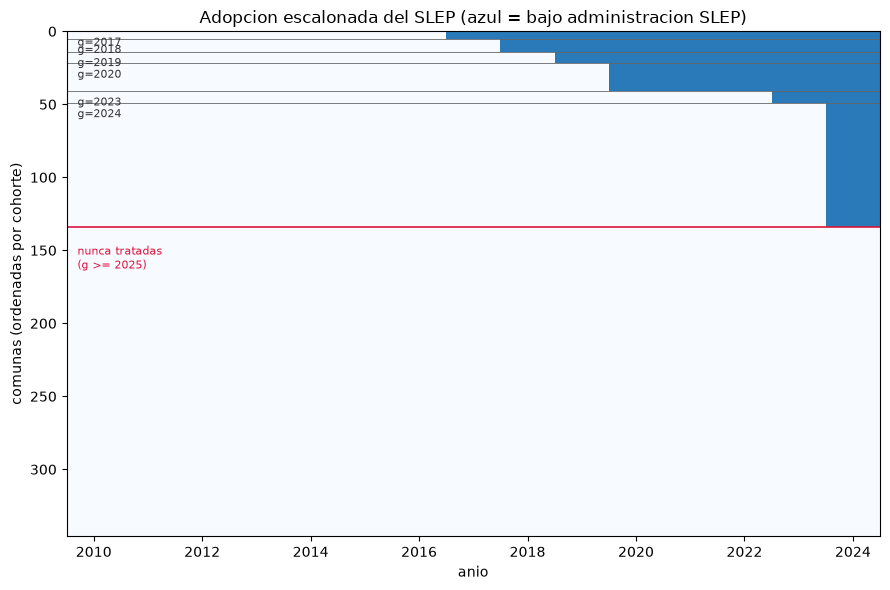

In [7]:
# Diagrama de adopcion: cada fila una comuna, ordenada por cohorte.
orden = panel[panel.anio == 2024].sort_values(["g", "clave"]).clave.tolist()
pos = {c: i for i, c in enumerate(orden)}
M = np.zeros((len(orden), len(ANIOS)))
for r in panel.itertuples():
    M[pos[r.clave], r.anio - 2010] = 1.0 if r.anio >= r.g else 0.0

fig, ax = plt.subplots(figsize=(9, 6))
ax.imshow(M, aspect="auto", cmap="Blues", vmin=0, vmax=1.4,
          extent=[2009.5, 2024.5, len(orden), 0], interpolation="nearest")
for g in COHORTES:
    y = min(pos[c] for c in orden if anio_slep[c] == g)
    ax.axhline(y, color="0.4", lw=0.6)
    ax.text(2009.7, y + 4, f"g={g}", fontsize=8, color="0.2", va="top")
ax.axhline(min(pos[c] for c in orden if anio_slep[c] >= 2025), color="crimson", lw=1.2)
ax.text(2009.7, min(pos[c] for c in orden if anio_slep[c] >= 2025) + 12,
        "nunca tratadas\n(g >= 2025)", fontsize=8, color="crimson", va="top")
ax.set_xlabel("anio"); ax.set_ylabel("comunas (ordenadas por cohorte)")
ax.set_title("Adopcion escalonada del SLEP (azul = bajo administracion SLEP)")
plt.tight_layout(); plt.show()

## 2.2 El estimando y sus supuestos

Sea $Y_{it}(0)$ la tasa que la comuna $i$ habría tenido en el año $t$ **sin**
traspaso, e $Y_{it}(1)$ la que habría tenido con él. Lo que queremos es el efecto
promedio sobre las tratadas (*average treatment effect on the treated*):

$$ATT(g, t) = E\big[\,Y_{it}(1) - Y_{it}(0) \;\big|\; G_i = g\,\big], \qquad t \geq g$$

De cada comuna observamos sólo una de las dos ramas, así que $Y_{it}(0)$ para una
comuna ya tratada hay que **imputarlo**. De ahí los supuestos:

1. **Tendencias paralelas.** Sin el traspaso, la tasa de las tratadas habría
   evolucionado en paralelo a la de las no tratadas. Es el supuesto de fondo, y
   es el que deja huella: si vale después, debería valer *antes*, y eso sí se
   puede mirar.
2. **Sin anticipación.** Las comunas no cambian su comportamiento antes de $g$
   porque saben que el traspaso viene. Discutible aquí: el calendario era ley
   desde 2017.
3. **SUTVA.** El traspaso de una comuna no afecta a las otras. También
   discutible: un estudiante puede matricularse en la comuna vecina.

> **Lo que un DiD no arregla.** Sigue habiendo selección — el calendario no fue
> aleatorio, priorizó ciertos territorios. Lo que el DiD permite es que las
> tratadas sean **distintas en nivel** (eso lo absorbe el efecto fijo de comuna).
> Lo que no permite es que sean distintas en **trayectoria**. Ese es el supuesto,
> y no es gratis.

## 2.3 Un tratamiento diluido

La hoja de comuna no separa por sostenedor, así que la tasa que modelamos incluye
a los colegios particulares, a los que el traspaso no toca. Estamos estimando una
**intención de tratar** a nivel comunal: el efecto de que *la comuna* pase a SLEP
sobre la tasa de *todos* sus estudiantes.

Si el efecto opera sólo sobre los estudiantes municipales/SLEP —cerca del 38 % de
la matrícula nacional— el efecto sobre **ellos** es aproximadamente
$1/0{,}38 \approx 2{,}6$ veces el que estimemos. Es un factor de escala, no un
sesgo: no cambia el signo ni la significancia, pero hay que aplicarlo antes de
interpretar cualquier magnitud.

---
# 3. Primer modelo: el que sale mal

Empecemos por lo obvio. Modelamos los desvinculados como un conteo binomial
sobre la matrícula, con efecto fijo de comuna, efecto fijo de año y un único
coeficiente de tratamiento:

$$\text{desv}_{it} \sim \text{Binomial}(M_{it},\, p_{it}), \qquad
\operatorname{logit} p_{it} = \alpha_i + \gamma_t + \tau D_{it}$$

donde $D_{it} = \mathbb{1}[t \geq g_i]$. Los $\alpha_i$ absorben que unas comunas
desvinculan más que otras siempre; los $\gamma_t$ absorben los shocks comunes a
todo el país —incluida la pandemia—; y $\tau$ es lo que sobra.

Es la especificación de manual. Vamos a estimarla y después a mostrar por qué
su intervalo de credibilidad es ficción.

In [8]:
d = panel.dropna(subset=["desv", "mat"]).query("mat > 0").copy()
comunas = sorted(d.clave.unique())
ic = {c: i for i, c in enumerate(comunas)}
it_ = {a: i for i, a in enumerate(ANIOS)}
d["i"] = d.clave.map(ic)
d["t"] = d.anio.map(it_)
d["D"] = ((d.g <= 2024) & (d.anio >= d.g)).astype(float)

n_obs = d.mat.values.astype(int)
y_obs = d.desv.values.astype(int)
print(f"{len(d)} observaciones comuna-anio, {len(comunas)} comunas")


def efectos_fijos(nombre_extra, columnas):
    # Esqueleto comun: intercepto jerarquico por comuna + efecto de anio.
    # Devuelve el predictor lineal; el bloque `with` lo cierra quien llama.
    mu = pm.Normal("mu", -4.0, 1.5)
    sc = pm.HalfNormal("sigma_comuna", 1.0)
    alpha = pm.Deterministic("alpha", mu + sc * pm.Normal("z_comuna", 0, 1,
                                                          shape=len(comunas)))
    sy = pm.HalfNormal("sigma_anio", 1.0)
    gamma = pm.Deterministic("gamma", sy * pm.Normal("z_anio", 0, 1, shape=len(ANIOS)))
    eta = alpha[d.i.values] + gamma[d.t.values]
    coefs = {}
    for nombre, x in columnas.items():
        b = pm.Normal(nombre, 0, 0.5)
        coefs[nombre] = b
        eta = eta + b * np.asarray(x, dtype=float)
    return eta, coefs


with pm.Model() as m_binomial:
    eta, _ = efectos_fijos("tau", {"tau": d.D.values})
    pm.Binomial("y", n=n_obs, logit_p=eta, observed=y_obs)
    idata_bin = pm.sample(500, tune=500, chains=4, cores=4, target_accept=0.9,
                          random_seed=SEMILLA, progressbar=False)

_ = resumen(idata_bin, "tau", etiqueta="tau (binomial)")

5182 observaciones comuna-anio, 346 comunas


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


tau (binomial)           logit -0.0454 [-0.0585, -0.0326]   -0.067 pp [-0.085, -0.048]   [ess 2882, r_hat 1.00]


## 3.1 Por qué ese intervalo es mentira

El modelo binomial afirma algo muy fuerte: que **toda** la variación de la tasa
de una comuna en torno a $\alpha_i + \gamma_t$ es ruido de muestreo, el de tirar
$M_{it}$ monedas. Con matrículas de miles de estudiantes, ese ruido es
minúsculo, y de ahí sale un intervalo estrechísimo.

Pero las comunas no son monedas. Una comuna puede tener un año malo por razones
que no son azar binomial: cierre de un liceo, un cambio de administración, una
crisis local. Eso es **sobredispersión**, y se mide comparando la varianza
observada de los residuos con la que el binomial predice.

La forma bayesiana de mirarlo es una **verificación predictiva posterior**:
simular datos del modelo ajustado y preguntar si se parecen a los reales en la
dimensión que importa.

In [9]:
with m_binomial:
    ppc = pm.sample_posterior_predictive(idata_bin, random_seed=SEMILLA,
                                         progressbar=False)

sim = ppc.posterior_predictive["y"].values.reshape(-1, len(d))


def dispersion(y, n, p):
    # Chi2 de Pearson por grado de libertad. 1.0 = el binomial es exacto.
    return np.mean((y - n * p) ** 2 / (n * p * (1 - p)))


p_hat = (idata_bin.posterior["alpha"].values.reshape(-1, len(comunas))[:, d.i.values]
         + idata_bin.posterior["gamma"].values.reshape(-1, len(ANIOS))[:, d.t.values])
p_hat = 1 / (1 + np.exp(-p_hat))

obs = dispersion(y_obs, n_obs, p_hat.mean(axis=0))
rep = np.array([dispersion(sim[s], n_obs, p_hat[s]) for s in range(0, len(sim), 5)])

print(f"dispersion observada : {obs:.2f}")
print(f"dispersion simulada  : {rep.mean():.2f}  [{np.percentile(rep, 2.5):.2f}, "
      f"{np.percentile(rep, 97.5):.2f}]")
print(f"\nLos datos reales estan {obs / rep.mean():.1f}x mas dispersos de lo que el "
      f"modelo puede generar.")
print(f"Los errores estandar binomiales subestiman por un factor ~{np.sqrt(obs):.1f}.")

_ = check("el binomial NO reproduce la dispersion de los datos",
      obs > np.percentile(rep, 97.5),
      "si pasara la prueba, el modelo simple bastaria")

dispersion observada : 10.19
dispersion simulada  : 1.01  [0.97, 1.05]

Los datos reales estan 10.1x mas dispersos de lo que el modelo puede generar.
Los errores estandar binomiales subestiman por un factor ~3.2.
[OK      ] el binomial NO reproduce la dispersion de los datos


---
# 4. El modelo que corresponde

Hay que darle al modelo una fuente de variación que el binomial no tiene: un
shock propio de cada comuna-año, $\varepsilon_{it}$, con desviación $\sigma_\varepsilon$
en escala logit.

En vez de declarar 5 182 parámetros latentes, usamos una construcción estándar y
mucho más rápida. Para cada celda calculamos el **logit empírico** y su varianza
de muestreo conocida (con la corrección de continuidad de Haldane–Anscombe, que
evita el infinito cuando no hay desvinculados):

$$y_{it} = \log\frac{\text{desv}_{it} + 0.5}{M_{it} - \text{desv}_{it} + 0.5},
\qquad v_{it} = \frac{1}{\text{desv}_{it} + 0.5} + \frac{1}{M_{it} - \text{desv}_{it} + 0.5}$$

y modelamos

$$y_{it} \sim \mathcal{N}\big(\alpha_i + \gamma_t + \tau D_{it},\;
\sqrt{v_{it} + \sigma_\varepsilon^2}\big)$$

La varianza tiene dos piezas: $v_{it}$ es el ruido de contar, distinto en cada
celda; $\sigma_\varepsilon^2$ es la dispersión real, común. Esto hace sola la cosa
correcta con la ponderación: una comuna de 200 estudiantes tiene $v$ grande y pesa
poco; una de 200 mil tiene $v \approx 0$ y pesa todo lo que $\sigma_\varepsilon$
permite — que no es infinito. **Ningún tamaño de comuna domina.**

---
## Ejercicio 1 — El modelo con dispersión

Declare el modelo. Es el mismo esqueleto de `efectos_fijos`, cambiando sólo la
verosimilitud.

In [10]:
a_ = d.desv.values + 0.5
b_ = d.mat.values - d.desv.values + 0.5
d["ylogit"] = np.log(a_ / b_)
d["v"] = 1 / a_ + 1 / b_

print(f"varianza de muestreo v: mediana {d.v.median():.4f}, "
      f"p10 {d.v.quantile(.1):.4f} (comunas grandes), "
      f"p90 {d.v.quantile(.9):.4f} (comunas chicas)")


def ajustar(columnas, datos=None, draws=500, semilla=SEMILLA):
    # DiD con dispersion: logit empirico ~ Normal(EF comuna + EF anio + efectos).
    global d
    dd = d if datos is None else datos
    ii = dd.clave.map(ic).values
    tt = dd.anio.map(it_).values
    with pm.Model() as modelo:
        mu = pm.Normal("mu", -4.0, 1.5)
        sc = pm.HalfNormal("sigma_comuna", 1.0)
        alpha = mu + sc * pm.Normal("z_comuna", 0, 1, shape=len(comunas))
        sy = pm.HalfNormal("sigma_anio", 1.0)
        gamma = sy * pm.Normal("z_anio", 0, 1, shape=len(ANIOS))
        eta = alpha[ii] + gamma[tt]
        for nombre, x in columnas.items():
            eta = eta + pm.Normal(nombre, 0, 0.5) * np.asarray(x, dtype=float)
        s_eps = pm.HalfNormal("sigma_eps", 0.5)
        pm.Normal("y", mu=eta, sigma=pm.math.sqrt(dd.v.values + s_eps ** 2),
                  observed=dd.ylogit.values)
        idata = pm.sample(draws, tune=draws, chains=4, cores=4, target_accept=0.9,
                          random_seed=semilla, progressbar=False)
    return idata


idata_did = ajustar({"tau": d.D.values})
print()
_ = resumen(idata_did, "sigma_eps", etiqueta="sigma_eps (dispersion)",
            solo_logit=True)
_ = resumen(idata_did, "tau", etiqueta="tau (con dispersion)")

varianza de muestreo v: mediana 0.0222, p10 0.0024 (comunas grandes), p90 0.1340 (comunas chicas)


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details



sigma_eps (dispersion)   logit +0.2417 [+0.2351, +0.2483]   [ess 2195, r_hat 1.00]
tau (con dispersion)     logit +0.0412 [-0.0011, +0.0840]   +0.063 pp [-0.002, +0.131]   [ess 1740, r_hat 1.00]


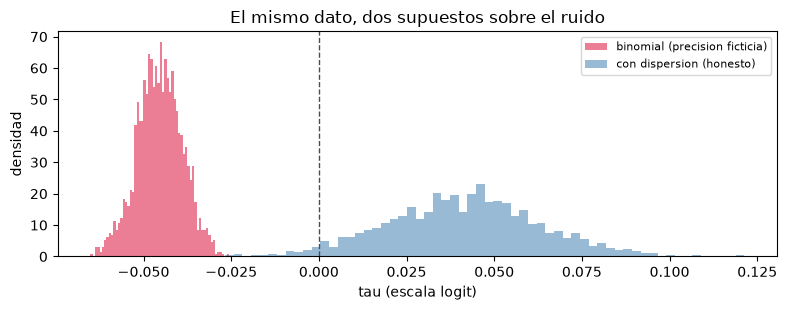

ancho del IC95 binomial       : 0.0259
ancho del IC95 con dispersion : 0.0851
[OK      ] el modelo honesto es mucho menos preciso

binomial       : -0.0454  (-0.067 pp)
con dispersion : +0.0412  (+0.063 pp)
[OK      ] las dos verosimilitudes discrepan en el signo del efecto


In [11]:
# Comparacion directa: el mismo tau bajo las dos verosimilitudes.
t_bin = idata_bin.posterior["tau"].values.reshape(-1)
t_did = idata_did.posterior["tau"].values.reshape(-1)

fig, ax = plt.subplots(figsize=(8, 3.2))
for m, etiq, col in [(t_bin, "binomial (precision ficticia)", "crimson"),
                     (t_did, "con dispersion (honesto)", "steelblue")]:
    ax.hist(m, bins=60, density=True, alpha=0.55, color=col, label=etiq)
ax.axvline(0, color="0.3", ls="--", lw=1)
ax.set_xlabel("tau (escala logit)"); ax.set_ylabel("densidad")
ax.set_title("El mismo dato, dos supuestos sobre el ruido")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

print(f"ancho del IC95 binomial       : {np.diff(np.percentile(t_bin, [2.5, 97.5]))[0]:.4f}")
print(f"ancho del IC95 con dispersion : {np.diff(np.percentile(t_did, [2.5, 97.5]))[0]:.4f}")
check("el modelo honesto es mucho menos preciso",
      np.diff(np.percentile(t_did, [2.5, 97.5]))[0]
      > 2 * np.diff(np.percentile(t_bin, [2.5, 97.5]))[0])
# Y hay algo peor que la anchura. Los dos modelos ni siquiera coinciden en el
# SIGNO del efecto: mismos datos, misma especificacion, unica diferencia el
# supuesto sobre el ruido.
print(f"\nbinomial       : {t_bin.mean():+.4f}  ({pp(t_bin.mean()):+.3f} pp)")
print(f"con dispersion : {t_did.mean():+.4f}  ({pp(t_did.mean()):+.3f} pp)")
_ = check("las dos verosimilitudes discrepan en el signo del efecto",
          np.sign(t_bin.mean()) != np.sign(t_did.mean()),
          "")

---
# 5. Comparaciones prohibidas

Antes de seguir, note lo que acaba de pasar: **el signo del efecto cambió**. El
modelo binomial daba −0,067 pp (el SLEP desvincula menos); el modelo con
dispersión da +0,063 pp (desvincula más). Mismos datos, misma especificación; lo
único que cambió es el supuesto sobre el ruido, que redistribuye el peso entre
comunas grandes y chicas. Guarde eso: es la primera señal de que el resultado no
está determinado por los datos.

Y hay un problema más, específico del diseño escalonado. La regresión anterior
tiene **un solo** $\tau$ y efectos fijos de año. Para estimarlos, el modelo usa
toda la variación disponible — incluida una comparación que no debería hacer:
**una comuna tratada en 2017 sirviendo de control para una tratada en 2024**.

Goodman-Bacon (2021) mostró que el estimador de dos vías es un promedio
ponderado de todas las comparaciones 2×2 posibles, y que ese promedio incluye
las «prohibidas» (ya-tratada como control) **con pesos que pueden ser
negativos**. Si el efecto cambia con el tiempo desde el traspaso, eso basta para
invertir el signo del resultado.

La solución de Callaway y Sant'Anna (2021) es no promediar nada a ciegas:
estimar cada $ATT(g)$ **contra el grupo limpio** —las nunca tratadas— y recién
después agregar, con pesos que uno elige y puede defender.

---
## Ejercicio 2 — ATT por cohorte

Estime, para cada cohorte $g$, el efecto usando **sólo** las comunas nunca
tratadas como control. Compare el agregado contra el $\tau$ único.

In [12]:
NUNCA = d[d.g >= 2025]
att = {}

print(f"{'cohorte':>8}{'comunas':>9}{'logit':>10}{'IC95':>18}{'pp':>9}{'matricula':>12}")
print("-" * 68)
for g in COHORTES:
    sub = pd.concat([d[d.g == g], NUNCA])
    D = ((sub.g == g) & (sub.anio >= g)).astype(float).values
    post = ajustar({"att": D}, datos=sub, draws=400).posterior["att"].values.reshape(-1)
    peso = d[(d.g == g) & (d.anio == 2024)].mat.sum()
    att[g] = (post, peso)
    lo, hi = np.percentile(post, [2.5, 97.5])
    print(f"{g:>8}{(d.g == g).sum() // 15:>9}{post.mean():>+10.4f}"
          f"   [{lo:+.3f}, {hi:+.3f}]{pp(post.mean()):>+9.3f}{peso:>12,.0f}")

 cohorte  comunas     logit              IC95       pp   matricula
--------------------------------------------------------------------


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


    2017        5   +0.0660   [-0.049, +0.184]   +0.102      90,669


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


    2018        9   -0.1876   [-0.291, -0.087]   -0.257      30,853


...

    2020       19   +0.0512   [-0.023, +0.121]   +0.079     167,566


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


    2023        8   +0.3456   [+0.204, +0.488]   +0.619     122,381


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


    2024       84   +0.1249   [+0.038, +0.205]   +0.200     504,427


In [13]:
# Agregacion. El peso NO es un detalle tecnico: define el estimando.
m = min(len(p) for p, _ in att.values())
P = np.stack([att[g][0][:m] for g in COHORTES])
w_est = np.array([att[g][1] for g in COHORTES], float); w_est /= w_est.sum()
w_com = np.array([(d.g == g).sum() // 15 for g in COHORTES], float); w_com /= w_com.sum()

agg_est = (w_est[:, None] * P).sum(axis=0)     # cada ESTUDIANTE pesa 1
agg_com = (w_com[:, None] * P).sum(axis=0)     # cada COMUNA pesa 1

print("Estimando 'efecto sobre el estudiante promedio tratado':")
print(f"  logit {agg_est.mean():+.4f} "
      f"[{np.percentile(agg_est, 2.5):+.4f}, {np.percentile(agg_est, 97.5):+.4f}]"
      f"   {pp(agg_est.mean()):+.3f} pp")
print("Estimando 'efecto sobre la comuna promedio tratada':")
print(f"  logit {agg_com.mean():+.4f} "
      f"[{np.percentile(agg_com, 2.5):+.4f}, {np.percentile(agg_com, 97.5):+.4f}]"
      f"   {pp(agg_com.mean()):+.3f} pp")
print("TWFE con un solo tau (incluye comparaciones prohibidas):")
print(f"  logit {t_did.mean():+.4f} "
      f"[{np.percentile(t_did, 2.5):+.4f}, {np.percentile(t_did, 97.5):+.4f}]"
      f"   {pp(t_did.mean()):+.3f} pp")

_ = check("los IC de las cohortes se solapan poco: el efecto NO es homogeneo",
      np.percentile(att[2018][0], 97.5) < np.percentile(att[2023][0], 2.5),
      "con efectos heterogeneos, promediar a ciegas es peligroso")

Estimando 'efecto sobre el estudiante promedio tratado':
  logit +0.1204 [+0.0690, +0.1724]   +0.192 pp
Estimando 'efecto sobre la comuna promedio tratada':
  logit +0.1018 [+0.0472, +0.1580]   +0.161 pp
TWFE con un solo tau (incluye comparaciones prohibidas):
  logit +0.0412 [-0.0011, +0.0840]   +0.063 pp
[OK      ] los IC de las cohortes se solapan poco: el efecto NO es homogeneo


> **Lo que aparece aquí.** Las cohortes no dicen lo mismo, y no por poco. La de
> 2018 —Huasco y Costa Araucanía, nueve comunas rurales chicas— da un efecto
> **negativo** de −0,25 pp; la de 2023 —Elqui y Costa Central— da uno **positivo**
> de +0,62 pp. Sus intervalos ni se rozan. No es ruido: es que «el efecto del
> SLEP» no es un número, o si lo es, estas cohortes no lo están midiendo.
>
> Con esa heterogeneidad, el agregado depende enteramente de con qué pesos se
> promedie, y el $\tau$ único del modelo anterior (+0,065 pp) queda por debajo de
> los dos agregados limpios (+0,19 y +0,16 pp) — la firma de las comparaciones
> prohibidas, que arrastran el promedio hacia las cohortes viejas.

---
# 6. La prueba que el diseño se hace a sí mismo

Todo lo anterior asume tendencias paralelas. Ese supuesto es sobre el
contrafactual y por eso es indemostrable — pero tiene una consecuencia
observable: si tratadas y controles evolucionaban igual, entonces **antes** del
traspaso no debería haber ninguna diferencia sistemática entre ellas.

El **estudio de eventos** lo mira directamente. Reemplazamos el único $\tau$ por
un coeficiente para cada año relativo al tratamiento:

$$y_{it} = \alpha_i + \gamma_t + \sum_{k \neq -1} \theta_k \,\mathbb{1}[t - g_i = k]
+ \varepsilon_{it}$$

con $k = -1$ (el año previo) como referencia. Los $\theta_k$ con $k < 0$ **no
son efectos**: son un test. Deberían ser cero. Los $\theta_k$ con $k \geq 0$ son
la dinámica del efecto.

---
## Ejercicio 3 — Estudio de eventos

Construya las columnas de tiempo relativo (agrupando los extremos para no
quedarse sin datos), estime, y grafique con sus intervalos.

In [14]:
K = [-6, -5, -4, -3, -2, 0, 1, 2, 3, 4, 5, 6]        # -1 es la referencia
d["kb"] = d.k.where(d.tratada, np.nan)
d.loc[d.tratada & (d.k <= -6), "kb"] = -6            # extremos agrupados
d.loc[d.tratada & (d.k >= 6), "kb"] = 6

cols = {f"k{k:+d}".replace("+", "p").replace("-", "m"): (d.kb == k).astype(float)
        for k in K}
idata_ev = ajustar(cols, draws=600)

nombres = list(cols)
print(f"{'k':>4}{'n obs':>8}{'logit':>10}{'IC95':>20}{'pp':>9}")
print("-" * 52)
TH = {}
for k, nom in zip(K, nombres):
    post = idata_ev.posterior[nom].values.reshape(-1)
    TH[k] = post
    lo, hi = np.percentile(post, [2.5, 97.5])
    marca = "  <- pre" if k < 0 else ""
    print(f"{k:>+4}{int((d.kb == k).sum()):>8}{post.mean():>+10.4f}"
          f"   [{lo:+.3f}, {hi:+.3f}]{pp(post.mean()):>+9.3f}{marca}")

The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


   k   n obs     logit                IC95       pp
----------------------------------------------------
  -6     991   -0.0315   [-0.081, +0.018]   -0.047  <- pre
  -5     133   +0.0122   [-0.057, +0.084]   +0.018  <- pre
  -4     133   -0.0375   [-0.108, +0.034]   -0.055  <- pre
  -3     133   +0.0482   [-0.023, +0.121]   +0.074  <- pre
  -2     133   +0.0440   [-0.026, +0.114]   +0.067  <- pre
  +0     133   +0.0784   [+0.007, +0.152]   +0.122
  +1      49   +0.0278   [-0.071, +0.121]   +0.042
  +2      41   -0.0425   [-0.150, +0.064]   -0.062
  +3      41   +0.0360   [-0.066, +0.137]   +0.055
  +4      41   +0.0468   [-0.059, +0.146]   +0.072
  +5      22   -0.0213   [-0.157, +0.116]   -0.032
  +6      19   +0.0331   [-0.112, +0.181]   +0.050


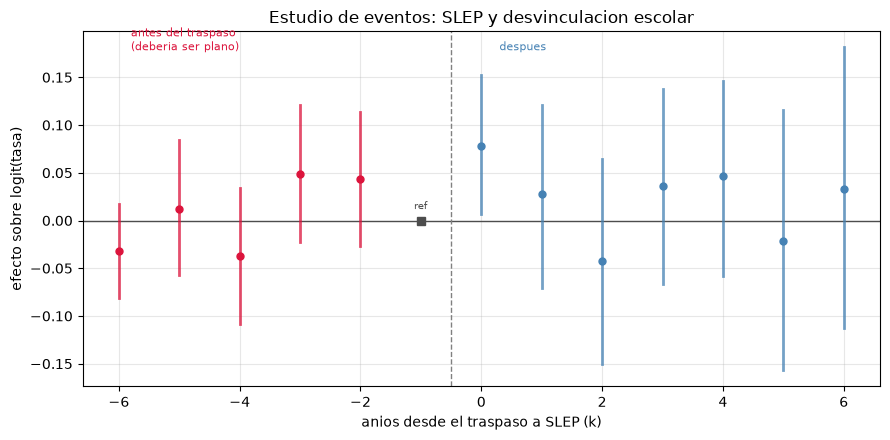

In [15]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ks = sorted(TH)
med = [TH[k].mean() for k in ks]
lo = [np.percentile(TH[k], 2.5) for k in ks]
hi = [np.percentile(TH[k], 97.5) for k in ks]
col = ["crimson" if k < 0 else "steelblue" for k in ks]

ax.axhline(0, color="0.3", lw=1)
ax.axvline(-0.5, color="0.5", ls="--", lw=1)
for k, m_, l_, h_, c in zip(ks, med, lo, hi, col):
    ax.plot([k, k], [l_, h_], color=c, lw=2, alpha=0.75)
    ax.plot(k, m_, "o", color=c, ms=5)
ax.plot(-1, 0, "s", color="0.3", ms=6)
ax.text(-1, 0.012, "ref", ha="center", fontsize=7, color="0.3")
ax.text(-5.8, ax.get_ylim()[1] * 0.9, "antes del traspaso\n(deberia ser plano)",
        fontsize=8, color="crimson")
ax.text(0.3, ax.get_ylim()[1] * 0.9, "despues", fontsize=8, color="steelblue")
ax.set_xlabel("anios desde el traspaso a SLEP (k)")
ax.set_ylabel("efecto sobre logit(tasa)")
ax.set_title("Estudio de eventos: SLEP y desvinculacion escolar")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [16]:
# Test conjunto: bajo tendencias paralelas, TODOS los theta_k previos son cero.
# Version bayesiana: que tan lejos del vector cero cae la posterior conjunta.
pre = [k for k in K if k < 0]
Pre = np.stack([TH[k] for k in pre])                    # (n_pre, draws)
centro = Pre.mean(axis=1)
S = np.cov(Pre)
maha = centro @ np.linalg.solve(S, centro)              # distancia de Mahalanobis^2
from scipy import stats
p_val = 1 - stats.chi2.cdf(maha, len(pre))

print(f"coeficientes previos (k = {pre}):")
print(f"  distancia al cero: chi2 = {maha:.1f} con {len(pre)} gl   ->  p = {p_val:.4f}")

mayor_pre = max(abs(TH[k].mean()) for k in pre)
mayor_post = max(abs(TH[k].mean()) for k in K if k >= 0)
print(f"\nmayor |theta| ANTES del traspaso : {mayor_pre:.4f}  ({pp(mayor_pre):+.3f} pp)")
print(f"mayor |theta| DESPUES            : {mayor_post:.4f}  ({pp(mayor_post):+.3f} pp)")

check("las tendencias previas son planas (tendencias paralelas)", p_val > 0.05,
      "el supuesto de identificacion NO se sostiene en los datos")
_ = check("el efecto posterior supera al ruido previo", mayor_post > 2 * mayor_pre,
      "los efectos 'post' son del mismo tamano que las diferencias 'pre'")

coeficientes previos (k = [-6, -5, -4, -3, -2]):
  distancia al cero: chi2 = 13.0 con 5 gl   ->  p = 0.0235

mayor |theta| ANTES del traspaso : 0.0482  (+0.074 pp)
mayor |theta| DESPUES            : 0.0784  (+0.122 pp)
[REVISAR ] las tendencias previas son planas (tendencias paralelas)   -> el supuesto de identificacion NO se sostiene en los datos
[REVISAR ] el efecto posterior supera al ruido previo   -> los efectos 'post' son del mismo tamano que las diferencias 'pre'


> **Las dos verificaciones fallan, y fallan juntas.** Los coeficientes previos no
> son cero ($p = 0{,}02$): las comunas que iban a ser traspasadas ya se movían
> distinto que las demás años antes del traspaso. Y el mayor efecto posterior
> (+0,12 pp, en $k=0$) es apenas 1,6 veces la mayor diferencia previa (+0,07 pp),
> cuando debería destacar sobre ella.
>
> Mírelo en el gráfico sin buscar la significancia: los puntos rojos —que por
> construcción **no** pueden ser efecto de nada— saltan tanto como los azules.
> Si el diseño no distingue el traspaso de lo que pasaba antes del traspaso, el
> número que entrega no es un efecto causal, por estrecho que sea su intervalo.
>
> Esto no dice «el SLEP no tuvo efecto». Dice algo más incómodo: **con estos
> datos no se puede separar el efecto del traspaso de la trayectoria que esas
> comunas ya traían.**

---
# 7. Placebo y robustez

El estudio de eventos ya condenó el diseño, pero conviene cuantificar el daño.
Un **placebo** hace la pregunta de la forma más cruda posible: si le inventamos
al tratamiento una fecha falsa, tres años *antes* de la verdadera, y estimamos
usando **sólo el período previo al traspaso real**, ¿cuánto efecto encontramos?

La respuesta debería ser cero. Todo lo que salga distinto de cero es el tamaño
del sesgo que este diseño produce sin que haya ningún tratamiento.

---
## Ejercicio 4 — Placebo y sensibilidad

In [17]:
# (a) Placebo: tratamiento falso en g-3, estimado solo con datos pre-traspaso.
pre_only = d[d.anio < d.g].copy()
Dp = ((pre_only.g <= 2024) & (pre_only.anio >= pre_only.g - 3)).astype(float).values
placebo = ajustar({"tau": Dp}, datos=pre_only, draws=400).posterior["tau"].values.reshape(-1)

print("PLACEBO (tratamiento falso en g-3, solo periodo previo):")
lo, hi = np.percentile(placebo, [2.5, 97.5])
print(f"  logit {placebo.mean():+.4f} [{lo:+.4f}, {hi:+.4f}]   {pp(placebo.mean()):+.3f} pp")
print("EFECTO REAL (mismo modelo, tratamiento verdadero):")
print(f"  logit {t_did.mean():+.4f} "
      f"[{np.percentile(t_did, 2.5):+.4f}, {np.percentile(t_did, 97.5):+.4f}]"
      f"   {pp(t_did.mean()):+.3f} pp")
print(f"\nEl placebo alcanza el {100 * abs(placebo.mean()) / max(abs(t_did.mean()), 1e-9):.0f}% "
      f"del efecto 'real'.")

The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


PLACEBO (tratamiento falso en g-3, solo periodo previo):
  logit +0.0840 [+0.0460, +0.1245]   +0.131 pp
EFECTO REAL (mismo modelo, tratamiento verdadero):
  logit +0.0412 [-0.0011, +0.0840]   +0.063 pp

El placebo alcanza el 204% del efecto 'real'.


In [18]:
# (b) Sensibilidad: el resultado tiene que sobrevivir a decisiones arbitrarias.
pruebas = {}
pruebas["base (inicio en g)"] = t_did
for off in (1, -1):
    D = ((d.g <= 2024) & (d.anio >= d.g + off)).astype(float).values
    pruebas[f"inicio en g{off:+d}"] = ajustar({"tau": D}, draws=400
                                              ).posterior["tau"].values.reshape(-1)
sin_covid = d[~d.anio.isin([2020, 2021])]
pruebas["sin 2020-2021"] = ajustar({"tau": sin_covid.D.values}, datos=sin_covid,
                                   draws=400).posterior["tau"].values.reshape(-1)
pruebas["ponderado por estudiante"] = agg_est
pruebas["ponderado por comuna"] = agg_com

print(f"{'especificacion':<30}{'logit':>10}{'IC95':>20}{'pp':>9}{'signo':>8}")
print("-" * 77)
for nombre, post in pruebas.items():
    lo, hi = np.percentile(post, [2.5, 97.5])
    signo = "+" if post.mean() > 0 else "-"
    cero = "" if lo < 0 < hi else "  *"
    print(f"{nombre:<30}{post.mean():>+10.4f}   [{lo:+.3f}, {hi:+.3f}]"
          f"{pp(post.mean()):>+9.3f}{signo:>8}{cero}")
print("\n(*) el IC95 excluye el cero")

signos = {("+" if p.mean() > 0 else "-") for p in pruebas.values()}
check("todas las especificaciones coinciden en el signo", len(signos) == 1,
      "el punto estimado cambia de signo segun como se pondere")
_ = check("alguna especificacion excluye el cero",
      any(not (np.percentile(p, 2.5) < 0 < np.percentile(p, 97.5))
          for p in pruebas.values()),
      "ninguna distingue el efecto de cero")

The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


especificacion                     logit                IC95       pp   signo
-----------------------------------------------------------------------------
base (inicio en g)               +0.0412   [-0.001, +0.084]   +0.063       +
inicio en g+1                    -0.0018   [-0.053, +0.049]   -0.003       -
inicio en g-1                    +0.0589   [+0.022, +0.097]   +0.091       +  *
sin 2020-2021                    +0.0577   [+0.011, +0.102]   +0.089       +  *
ponderado por estudiante         +0.1204   [+0.069, +0.172]   +0.192       +  *
ponderado por comuna             +0.1018   [+0.047, +0.158]   +0.161       +  *

(*) el IC95 excluye el cero
[REVISAR ] todas las especificaciones coinciden en el signo   -> el punto estimado cambia de signo segun como se pondere
[OK      ] alguna especificacion excluye el cero


---
# 8. Conclusiones

**Sobre el diseño, primero.** El estudio de eventos rechazó las tendencias
paralelas ($p = 0{,}02$) y el placebo remató: un tratamiento con **fecha
inventada**, tres años antes del real y estimado sólo con datos previos al
traspaso, produce +0,131 pp — el **doble** del efecto «real» (+0,063 pp), y con
un intervalo que sí excluye el cero. Un diseño que encuentra un efecto grande
donde por construcción no puede haber ninguno no está midiendo efectos: está
midiendo la diferencia de trayectoria que ya existía entre las comunas que el
calendario de la Ley 21.040 priorizó y las demás.

**Sobre el SLEP, entonces.** No hay una estimación creíble del efecto del
traspaso sobre la desvinculación escolar. Lo que hay es un abanico de números que
depende de decisiones que los datos no zanjan:

| decisión | efecto estimado |
|---|---|
| verosimilitud binomial | −0,067 pp * |
| verosimilitud con dispersión (base) | +0,063 pp |
| primer año tratado = $g+1$ | −0,003 pp |
| excluyendo la pandemia | +0,089 pp * |
| agregando por estudiante | +0,192 pp * |
| agregando por comuna | +0,161 pp * |
| **placebo con fecha falsa** | **+0,131 pp *** |

<small>(*) el intervalo del 95 % excluye el cero.</small>

Ese cuadro es el resultado. El efecto estimado va de −0,067 a +0,192 pp
—**cambiando de signo**— según tres decisiones que ningún dato resuelve: qué se
supone del ruido, en qué año empieza el tratamiento (la ambigüedad entre creación
e instalación declarada en la sección 1.2), y si se pondera por estudiante o por
comuna. Varias de esas versiones son «significativas». Todas son menos
convincentes que el placebo que las acompaña.

Lo único afirmable con alguna base es negativo, y contradice la lectura de la
guía anterior: **nada aquí respalda que el SLEP desvincule menos que el sector
municipal.** Los puntos estimados, si algo, van en la otra dirección — pero no
son interpretables, y concluir que «el SLEP desvincula más» sería repetir el
mismo error con el signo cambiado.

**El arco de las tres guías.** Es el mismo error tres veces, cada vez mejor
disfrazado:

| | el estimador entregó | el problema |
|---|---|---|
| tasas crudas | −0,49 pp | ventana temporal distinta |
| ajuste por puerta trasera | −0,41 pp | positividad violada, escondida al agregar |
| DiD escalonado | −0,07 a +0,19 pp | tendencias paralelas rechazadas; el placebo supera al efecto |

En los tres casos **el cálculo corrió sin protestar** y devolvió un número con
intervalo estrecho. Ninguna biblioteca emitió una advertencia. Y en los tres la
única defensa fue la misma: no mirar el estimador sino sus supuestos — soporte
común en la guía 2, dispersión, tendencias previas y placebo en ésta. Un modelo
probabilístico dice qué se sigue *de sus supuestos*; verificar los supuestos no
es parte del cálculo, es el trabajo.

> **Lo que sí haría falta.** Datos a nivel de **establecimiento**, con su
> sostenedor y su fecha de traspaso. Eso permitiría comparar colegios municipales
> traspasados contra colegios municipales aún no traspasados —eliminando la
> dilución de la sección 2.3, que aquí multiplica por 2,6 cualquier magnitud— y
> construir controles comparables con covariables de nivel socioeconómico y
> ruralidad (emparejamiento, o DiD doblemente robusto). Con eso, las tendencias
> paralelas serían un supuesto defendible en vez de uno rechazado. Sin eso, la
> respuesta honesta a «¿funcionó la desmunicipalización?» sigue siendo **no lo
> sabemos** — y sostener eso frente a un resultado significativo es exactamente
> la competencia que esta guía pretende entrenar.

---
## Para pensar (sin entrega)

1. **Anticipación.** El calendario era ley desde 2017: una comuna que sabía que
   sería traspasada en 2025 pudo cambiar antes. Reestime el estudio de eventos
   usando $k = -4$ como referencia en vez de $k = -1$. ¿Cambian las conclusiones?
   ¿Qué referencia es defendible si no hay ningún $k$ «limpio»?

2. **Controles no tan limpios.** Usamos como control las comunas con
   $g \geq 2025$. Pero cinco de ellas entran recién en 2029, y otras en 2025.
   ¿Son igual de comparables? Reestime usando sólo las de $g \geq 2027$ y
   compare.

3. **Tendencias paralelas condicionales.** El supuesto puede valer *dentro* de
   grupos de comunas parecidas aunque falle en general. Agrupe las comunas por
   tamaño de matrícula (terciles) y estime el efecto por grupo. ¿En alguno se
   aplanan las tendencias previas?

4. **Honest DiD.** Rambachan y Roth (2023) proponen no exigir tendencias
   paralelas exactas, sino acotar cuánto pueden desviarse y reportar el rango de
   efectos compatible con esa cota. Con las magnitudes previas que estimó aquí,
   ¿qué cota sería creíble, y qué queda del efecto bajo esa cota?

5. **El otro resultado.** Toda la guía mide desvinculación. Con la misma
   estructura, ¿qué otro indicador de la planilla del MINEDUC sometería a este
   diseño, y por qué esperaría que ahí sí se vea algo?